# Recurrent Neural Networks
## The concept of "weight sharing"
Example of a fully connected network with three hidden layhers for a classification problem.

In [1]:
# Import dependencies
import torch
import torchvision
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import *
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from idlmam import *
from sklearn.metrics import accuracy_score

/home/efrain/Documents/Bio-AI-foundations/Inside_Deep_Learning/idlmam.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
# Import the dl_utils.py file
import sys, os

# Add the project root to the python path
sys.path.insert(0, os.path.abspath("../DL_utils_EZA")) # Goes up one level from current folder

# Autoreload: picks up edits to dl_utils.py without restarting the kernel
%load_ext autoreload
%autoreload 2

# Import my own utilities
from dl_utils import * #import all my functions

print(" dl_utils loaded")

 dl_utils loaded


In [3]:
# Verification of CUDA present and force deterministic bahaviour for reproducibility with forced GPU usage

torch.backends.cudnn.benchmark = True  # Speeds up CNN training with fixed input sizes

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device available: {device}')


Device available: cuda


In [4]:
# Load the MNIST data set
mnist_data_train = torchvision.datasets.MNIST("./data", train=True, download=False, transform=transforms.ToTensor())
mnist_data_test = torchvision.datasets.MNIST("./data", train=False, download=False, transform=transforms.ToTensor())

In [11]:
# Data Loader
mnist_train_loader = DataLoader(mnist_data_train, 
                                batch_size=128, 
                                shuffle=True, 
                                num_workers=6, 
                                pin_memory=True, 
                                persistent_workers=True,
                                drop_last=True
                                )
minst_test_loader = DataLoader(mnist_data_test, 
                               batch_size=2*128,
                               shuffle=False,
                               num_workers=6,
                               persistent_workers=True
                               )

# Hyperparameters
D = 28*28    # How many values are in the input. Used to determine of subsequent layers
n = 256      # Hidden layers size
C = 1        # Channels in the input
classes = 10 # number of classes

In [8]:
# Simple fully connected model
model_regular = nn.Sequential(
    Flatten(),
    nn.Linear(D, n),
    nn.Tanh(),
    nn.Linear(n, n),
    nn.Tanh(),
    nn.Linear(n, n),
    nn.Tanh(),
    nn.Linear(n, classes),
)

In [9]:
# Train the model
loss_func = nn.CrossEntropyLoss()
regular_results = train_simple_network_EZA(model_regular,
                                           loss_func,
                                           mnist_train_loader,
                                           test_loader=minst_test_loader,
                                           score_funcs={'Accuracy': accuracy_score},
                                           device=device,
                                           epochs=20
                                           )

Epoch: 100%|██████████| 20/20 [02:54<00:00,  8.75s/it]


In [12]:
# Model Shared weights
h_2 = nn.Linear(n, n)

model_shared = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n),
    nn.Tanh(),
    h_2,
    nn.Tanh(),
    h_2,
    nn.Tanh(),
    nn.Linear(n, classes)
)

In [13]:
shared_results = train_simple_network_EZA(model_shared,
                                           loss_func,
                                           mnist_train_loader,
                                           test_loader=minst_test_loader,
                                           score_funcs={'Accuracy': accuracy_score},
                                           device=device,
                                           epochs=20
                                           )

Epoch: 100%|██████████| 20/20 [01:00<00:00,  3.03s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

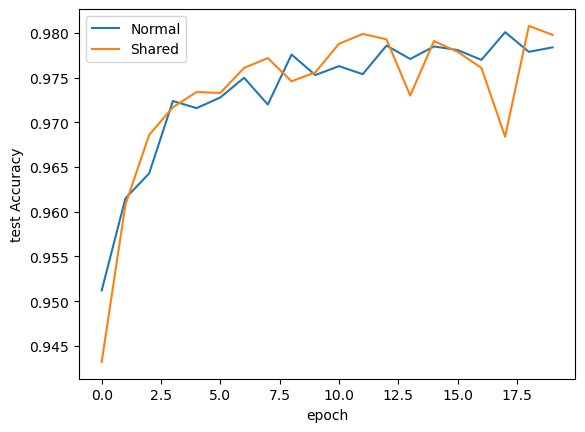

In [14]:
sns.lineplot(x='epoch', y='test Accuracy', data = regular_results, label='Normal')
sns.lineplot(x='epoch', y='test Accuracy', data = shared_results, label='Shared')